In [8]:
import os

def get_paired_data(image_dir, target_dir):
    paired_data = []

    # Ambil semua file di folder images
    all_files = sorted(os.listdir(image_dir))

    # Filter hanya gambar Pre-disaster dulu
    pre_files = [f for f in all_files if 'pre_disaster' in f]

    print(f"Sedang mencocokkan {len(pre_files)} gambar Pre-Disaster...")

    for pre_file in pre_files:
        post_file = pre_file.replace('pre_disaster', 'post_disaster')
        
        if post_file.endswith('.png'):
            target_file = post_file.replace('.png', '_target.png')
        else:
            continue # Skip jika bukan png

        pre_path = os.path.join(image_dir, pre_file)
        post_path = os.path.join(image_dir, post_file)
        target_path = os.path.join(target_dir, target_file)

        if os.path.exists(post_path) and os.path.exists(target_path):
            paired_data.append({
                'pre_img': pre_path,
                'post_img': post_path,
                'target_mask': target_path
            })

    return paired_data

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

In [10]:
class DisasterDataGenerator(Sequence):
    def __init__(self, pairs, batch_size=16, img_size=(256, 256)):
        self.pairs = pairs
        self.batch_size = batch_size
        self.img_size = img_size

    def __len__(self):
        return int(np.ceil(len(self.pairs) / self.batch_size))

    def __getitem__(self, index):
        batch_pairs = self.pairs[index * self.batch_size:(index + 1) * self.batch_size]
        
        images = []
        masks = []

        for pair in batch_pairs:
            img = cv2.imread(pair['post_img'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            img = img / 255.0
            images.append(img)

            mask = cv2.imread(pair['target_mask'], 0)
            mask = cv2.resize(mask, self.img_size)
            
            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)
            masks.append(mask)

        return np.array(images), np.array(masks)

In [11]:
def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c4)

    u5 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c7)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

Sedang mencocokkan 2799 gambar Pre-Disaster...
1. Pre Image  : train_images_labels_targets/train/images\guatemala-volcano_00000000_pre_disaster.png
2. Post Image : train_images_labels_targets/train/images\guatemala-volcano_00000000_post_disaster.png
3. Target Mask: train_images_labels_targets/train/targets\guatemala-volcano_00000000_post_disaster_target.png
Data Training: 2239 gambar
Data Validasi: 560 gambar
Epoch 1/5
280/280 [==============================] - -2055s -7404921us/step - loss: 0.2240 - accuracy: 0.9360 - val_loss: 0.2061 - val_accuracy: 0.9328
Epoch 2/5
280/280 [==============================] - 1237s 4s/step - loss: 0.1852 - accuracy: 0.9400 - val_loss: 0.2166 - val_accuracy: 0.9364
Epoch 3/5
280/280 [==============================] - 1232s 4s/step - loss: 0.1793 - accuracy: 0.9391 - val_loss: 0.1718 - val_accuracy: 0.9390
Epoch 4/5
280/280 [==============================] - -1883s -6765972us/step - loss: 0.1663 - accuracy: 0.9417 - val_loss: 0.1707 - val_accuracy: 0.93

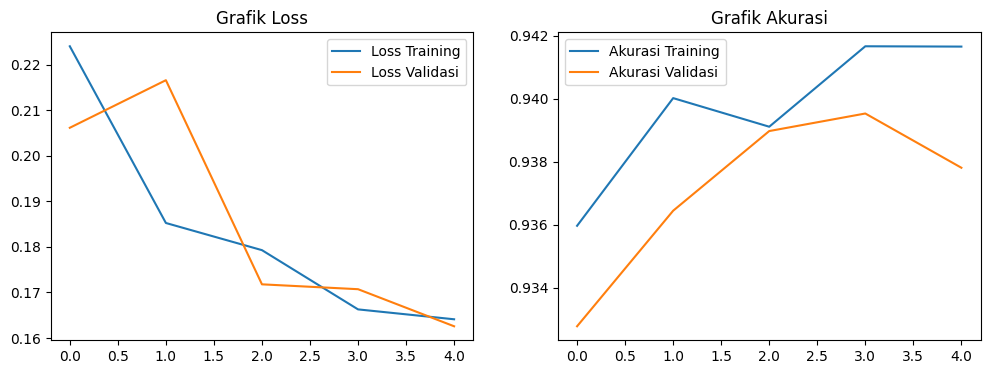

In [12]:
if __name__ == "__main__":
    images_path = 'train_images_labels_targets/train/images'
    targets_path = 'train_images_labels_targets/train/targets'

    dataset = []
    
    try:
        dataset = get_paired_data(images_path, targets_path)

        if len(dataset) > 0:
            print(f"1. Pre Image  : {dataset[0]['pre_img']}")
            print(f"2. Post Image : {dataset[0]['post_img']}")
            print(f"3. Target Mask: {dataset[0]['target_mask']}")

    except Exception as e:
        print(f"Error: {e}")
    
    if len(dataset) == 0:
        raise ValueError("No dataset found. Please check your paths.")
    
    train_pairs, val_pairs = train_test_split(dataset, test_size=0.2, random_state=42)
    
    print(f"Data Training: {len(train_pairs)} gambar")
    print(f"Data Validasi: {len(val_pairs)} gambar")

    batch_size = 8
    train_gen = DisasterDataGenerator(train_pairs, batch_size=batch_size)
    val_gen = DisasterDataGenerator(val_pairs, batch_size=batch_size)

    model = build_unet()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        verbose=1
    )

    model.save('model_tesis_jason.h5')
        
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss Training')
    plt.plot(history.history['val_loss'], label='Loss Validasi')
    plt.legend()
    plt.title('Grafik Loss')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Akurasi Training')
    plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
    plt.legend()
    plt.title('Grafik Akurasi')
    plt.show()